# GPT-2 Causal Patching

**Phase 3:** Activation patching for GPT-2 (Hispanic↔Black direction).

**Hardware:** M4 Mac Mini or A100  
**Runtime:** ~30 minutes  
**Run all cells top to bottom.**

**Outputs:**
- `results/causal_patching_gpt2_results.csv`
- KL values and same-group baseline for Table 2

**Expected outputs:**  
- Layer 3-6: KL = 0.017-0.018 (17-18x above baseline)  
- Layer 9: KL = 0.009  
- Layer 11 (final): KL = 0.000 (inert)

**Note:** Run `08_permutation_test_gpt2.ipynb` after this to get permutation-validated p-values.


## Cell 1: Setup

In [1]:
!pip install -q numpy==1.26.4
!pip install -q transformer_lens datasets pandas matplotlib

import json, os, torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from datasets import load_dataset
from transformer_lens import HookedTransformer

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
GPT2_LAYERS = [3, 6, 9, 11]
N_PAIRS = 10
os.makedirs('results', exist_ok=True)
print(f'Device: {DEVICE}')
print('Ready.')


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.9/239.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 58.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
plum-dispatch 2.8.0 requires beartype>=0.16.2, but you have beartype 0.14.1 which is incompatible.
Device: cuda
Ready.


## Cell 2: Load BBQ and build prompt pairs

In [2]:
dataset = load_dataset('Elfsong/BBQ', split='race_ethnicity')
race_df = dataset.to_pandas()
race_ambig = race_df[race_df['context_condition'] == 'ambig'].reset_index(drop=True)

group_indices = {'Hispanic': [], 'Black': []}
for i, row in race_ambig.iterrows():
    ctx = row['context']
    if 'Hispanic' in ctx:
        group_indices['Hispanic'].append(i)
    elif 'Black' in ctx and 'African American' not in ctx:
        group_indices['Black'].append(i)

hispanic_rows = race_ambig.iloc[group_indices['Hispanic'][:N_PAIRS]].reset_index(drop=True)
black_rows    = race_ambig.iloc[group_indices['Black'][:N_PAIRS]].reset_index(drop=True)
print(f'Hispanic: {len(hispanic_rows)} pairs, Black: {len(black_rows)} pairs')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/age-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

data/disability_status-00000-of-00001.pa(…):   0%|          | 0.00/85.2k [00:00<?, ?B/s]

data/gender_identity-00000-of-00001.parq(…):   0%|          | 0.00/217k [00:00<?, ?B/s]

...

Generating race_x_ses split:   0%|          | 0/11160 [00:00<?, ? examples/s]

Generating religion split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating ses split:   0%|          | 0/6864 [00:00<?, ? examples/s]

Generating sexual_orientation split:   0%|          | 0/864 [00:00<?, ? examples/s]

Hispanic: 10 pairs, Black: 10 pairs


## Cell 3: Load GPT-2

In [3]:
print('Loading GPT-2...')
model = HookedTransformer.from_pretrained('gpt2', device=DEVICE, dtype=torch.float32)
model.eval()
print('Loaded.')


Loading GPT-2...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Loaded.


## Cell 4: Patching functions

In [4]:
def format_prompt(row):
    return (
        f"Context: {row['context']}\n"
        f"Question: {row['question']}\n"
        f"A) {row['ans0']}\nB) {row['ans1']}\nC) {row['ans2']}\nAnswer:"
    )

def get_label_token_pos(prompt, model, target_word):
    tokens = model.to_tokens(prompt)
    strs = [model.to_string(tokens[0][i]) for i in range(tokens.shape[1])]
    pos = next((i for i, t in enumerate(strs) if target_word.strip() in t.strip()), None)
    return pos, tokens

def kl_divergence(logits_a, logits_b):
    p_a = F.softmax(logits_a.float(), dim=-1)
    p_b = F.softmax(logits_b.float(), dim=-1)
    return F.kl_div(p_b.log(), p_a, reduction='sum').item()

def patch_and_measure(source_prompt, target_prompt, source_label, target_label, layer):
    pos_src, src_tokens = get_label_token_pos(source_prompt, model, source_label)
    pos_tgt, tgt_tokens = get_label_token_pos(target_prompt, model, target_label)
    if pos_src is None or pos_tgt is None:
        return None
    with torch.no_grad():
        _, cache = model.run_with_cache(src_tokens)
    src_act = cache[f'blocks.{layer}.hook_resid_post'][0, pos_src, :].clone()
    orig_logits = model(tgt_tokens)[0, -1, :]
    def hook(value, hook):
        value[0, pos_tgt, :] = src_act
        return value
    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            tgt_tokens,
            fwd_hooks=[(f'blocks.{layer}.hook_resid_post', hook)]
        )[0, -1, :]
    return kl_divergence(orig_logits, patched_logits)

print('Patching functions defined.')


Patching functions defined.


## Cell 5: Run causal patching across all layers

In [5]:
print('CAUSAL PATCHING — GPT-2')
print('='*55)
results = []

for layer in GPT2_LAYERS:
    kls_h2b, kls_b2h = [], []
    for i in range(N_PAIRS):
        h_prompt = format_prompt(hispanic_rows.iloc[i])
        b_prompt = format_prompt(black_rows.iloc[i])
        kl = patch_and_measure(h_prompt, b_prompt, 'Hispanic', 'Black', layer)
        if kl is not None: kls_h2b.append(kl)
        kl = patch_and_measure(b_prompt, h_prompt, 'Black', 'Hispanic', layer)
        if kl is not None: kls_b2h.append(kl)

    for direction, kls in [('Hispanic→Black', kls_h2b), ('Black→Hispanic', kls_b2h)]:
        mean_kl = np.mean(kls)
        results.append({'model': 'GPT-2', 'layer': layer, 'direction': direction,
                        'mean_kl': round(mean_kl, 4), 'std_kl': round(np.std(kls), 4), 'n': len(kls)})
        print(f'  Layer {layer} {direction}: {mean_kl:.4f}')

df = pd.DataFrame(results)
df.to_csv('results/causal_patching_gpt2_results.csv', index=False)
print('\nSaved: results/causal_patching_gpt2_results.csv')
print('\nFull table:')
print(df.to_string(index=False))


CAUSAL PATCHING — GPT-2
  Layer 3 Hispanic→Black: 0.0173
  Layer 3 Black→Hispanic: 0.0181
  Layer 6 Hispanic→Black: 0.0171
  Layer 6 Black→Hispanic: 0.0194
  Layer 9 Hispanic→Black: 0.0088
  Layer 9 Black→Hispanic: 0.0097
  Layer 11 Hispanic→Black: 0.0000
  Layer 11 Black→Hispanic: 0.0000

Saved: results/causal_patching_gpt2_results.csv

Full table:
model  layer      direction  mean_kl  std_kl  n
GPT-2      3 Hispanic→Black   0.0173  0.0060 10
GPT-2      3 Black→Hispanic   0.0181  0.0096 10
GPT-2      6 Hispanic→Black   0.0171  0.0064 10
GPT-2      6 Black→Hispanic   0.0194  0.0102 10
GPT-2      9 Hispanic→Black   0.0088  0.0037 10
GPT-2      9 Black→Hispanic   0.0097  0.0048 10
GPT-2     11 Hispanic→Black   0.0000  0.0000 10
GPT-2     11 Black→Hispanic   0.0000  0.0000 10


## Cell 6: Same-group baseline
Confirms the null — patching within the same group should produce near-zero KL.

In [6]:
print('Same-group baseline (Hispanic→Hispanic at layer 6):')
baseline_kls = []
for i in range(min(6, N_PAIRS-1)):
    kl = patch_and_measure(
        format_prompt(hispanic_rows.iloc[i]),
        format_prompt(hispanic_rows.iloc[i+1]),
        'Hispanic', 'Hispanic', layer=6
    )
    if kl is not None: baseline_kls.append(kl)

print(f'  Same-group KL: {np.mean(baseline_kls):.4f} ± {np.std(baseline_kls):.4f}')
print(f'  (Paper reports: 0.001)')
print(f'  Signal/noise at layer 6: {df[df.layer==3]["mean_kl"].mean():.4f} / {np.mean(baseline_kls):.4f}')


Same-group baseline (Hispanic→Hispanic at layer 6):
  Same-group KL: 0.0013 ± 0.0016
  (Paper reports: 0.001)
  Signal/noise at layer 6: 0.0177 / 0.0013


## Cell 7b: White-Hispanic causal patching

In [7]:
# White-Hispanic causal patching (extends Hispanic-Black patching above)
# Tests whether the White-Hispanic direction is causally active —
# directly validates the criminalization-adjacent vocabulary finding in Section 4.4

N_PAIRS_WH = 10
GPT2_LAYERS = [3, 6, 9, 11]

# Build White rows
white_indices = []
for i, row in race_ambig.iterrows():
    ctx = row['context']
    if 'White' in ctx and 'Non-White' not in ctx:
        white_indices.append(i)
white_rows = race_ambig.iloc[white_indices[:N_PAIRS_WH]].reset_index(drop=True)
print(f'White rows: {len(white_rows)}')

# Run White-Hispanic patching
print('\nCAUSAL PATCHING — GPT-2 (White-Hispanic direction)')
print('='*55)
wh_results = []

for layer in GPT2_LAYERS:
    kls_w2h, kls_h2w = [], []
    for i in range(N_PAIRS_WH):
        w_prompt = format_prompt(white_rows.iloc[i])
        h_prompt = format_prompt(hispanic_rows.iloc[i])

        kl = patch_and_measure(w_prompt, h_prompt, 'White', 'Hispanic', layer)
        if kl is not None: kls_w2h.append(kl)
        kl = patch_and_measure(h_prompt, w_prompt, 'Hispanic', 'White', layer)
        if kl is not None: kls_h2w.append(kl)

    for direction, kls in [('White→Hispanic', kls_w2h), ('Hispanic→White', kls_h2w)]:
        mean_kl = np.mean(kls)
        wh_results.append({'model': 'GPT-2', 'layer': layer, 'direction': direction,
                           'mean_kl': round(mean_kl, 4), 'std_kl': round(np.std(kls), 4),
                           'n': len(kls)})
        print(f'  Layer {layer} {direction}: {mean_kl:.4f}')

# Same-group White baseline at layer 6
print('\nSame-group White baseline (layer 6):')
wh_baseline = []
for i in range(min(6, len(white_rows) - 1)):
    kl = patch_and_measure(
        format_prompt(white_rows.iloc[i]),
        format_prompt(white_rows.iloc[i+1]),
        'White', 'White', layer=6)
    if kl is not None: wh_baseline.append(kl)
print(f'  Same-group KL: {np.mean(wh_baseline):.4f} \u00b1 {np.std(wh_baseline):.4f}')

wh_df = pd.DataFrame(wh_results)
print('\nFull White-Hispanic table:')
print(wh_df.to_string(index=False))

wh_df.to_csv('results/causal_patching_gpt2_white_hispanic.csv', index=False)
print('\nSaved: results/causal_patching_gpt2_white_hispanic.csv')

# Quick comparison: same causal profile as Hispanic-Black?
print('\nCOMPARISON:')
hb_means = df.groupby('layer')['mean_kl'].mean()
wh_means = wh_df.groupby('layer')['mean_kl'].mean()
for layer in GPT2_LAYERS:
    print(f'  Layer {layer}: H-B={hb_means[layer]:.4f}  W-H={wh_means[layer]:.4f}')


White rows: 10

CAUSAL PATCHING — GPT-2 (White-Hispanic direction)
  Layer 3 White→Hispanic: 0.0163
  Layer 3 Hispanic→White: 0.0099
  Layer 6 White→Hispanic: 0.0181
  Layer 6 Hispanic→White: 0.0119
  Layer 9 White→Hispanic: 0.0095
  Layer 9 Hispanic→White: 0.0068
  Layer 11 White→Hispanic: 0.0000
  Layer 11 Hispanic→White: 0.0000

Same-group White baseline (layer 6):
  Same-group KL: 0.0002 ± 0.0002

Full White-Hispanic table:
model  layer      direction  mean_kl  std_kl  n
GPT-2      3 White→Hispanic   0.0163  0.0081 10
GPT-2      3 Hispanic→White   0.0099  0.0027 10
GPT-2      6 White→Hispanic   0.0181  0.0092 10
GPT-2      6 Hispanic→White   0.0119  0.0028 10
GPT-2      9 White→Hispanic   0.0095  0.0035 10
GPT-2      9 Hispanic→White   0.0068  0.0014 10
GPT-2     11 White→Hispanic   0.0000  0.0000 10
GPT-2     11 Hispanic→White   0.0000  0.0000 10

Saved: results/causal_patching_gpt2_white_hispanic.csv

COMPARISON:
  Layer 3: H-B=0.0177  W-H=0.0131
  Layer 6: H-B=0.0183  W-H=0.0150

In [8]:
# Helper functions for position ablation and paraphrase probe
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

def get_activation_at_pos(prompt, model, pos, layer):
    tokens = model.to_tokens(prompt)
    seq_len = tokens.shape[1]
    actual_pos = pos if pos >= 0 else seq_len + pos
    actual_pos = max(0, min(actual_pos, seq_len - 1))
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)
    return cache[f'blocks.{layer}.hook_resid_post'][0, actual_pos, :].float().cpu().numpy()

def get_label_pos(prompt, model, label):
    tokens = model.to_tokens(prompt)
    strs = [model.to_string(tokens[0][i]) for i in range(tokens.shape[1])]
    for i, t in enumerate(strs):
        if label.strip() in t.strip():
            return i
    return None

def probe_at_offset(rows_h, rows_b, model, layer, offset):
    X, y = [], []
    for _, row in rows_h.iterrows():
        prompt = format_prompt(row)
        label_pos = get_label_pos(prompt, model, 'Hispanic')
        if label_pos is None: continue
        pos = label_pos + offset if isinstance(offset, int) else \
              {'fixed_5': 5, 'fixed_15': 15, 'final': -1}[offset]
        act = get_activation_at_pos(prompt, model, pos, layer)
        X.append(act); y.append('Hispanic')
    for _, row in rows_b.iterrows():
        prompt = format_prompt(row)
        label_pos = get_label_pos(prompt, model, 'Black')
        if label_pos is None: continue
        pos = label_pos + offset if isinstance(offset, int) else \
              {'fixed_5': 5, 'fixed_15': 15, 'final': -1}[offset]
        act = get_activation_at_pos(prompt, model, pos, layer)
        X.append(act); y.append('Black')
    if len(set(y)) < 2: return None, None
    X = np.array(X); y = np.array(y)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr, te in cv.split(X, y):
        scaler = StandardScaler()
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(scaler.fit_transform(X[tr]), y[tr])
        scores.append(clf.score(scaler.transform(X[te]), y[te]))
    return np.mean(scores), np.std(scores)

print('Probe helpers defined.')

Probe helpers defined.


In [9]:
# Paraphrase probe — tests whether 100% accuracy survives label substitution
from sklearn.preprocessing import StandardScaler

def format_prompt_sub(row, sub_hispanic=None, sub_black=None):
    ctx = row['context']
    if sub_hispanic:
        ctx = ctx.replace('Hispanic', sub_hispanic)
    if sub_black:
        ctx = ctx.replace('Black', sub_black)
    return (f"Context: {ctx}\n"
            f"Question: {row['question']}\n"
            f"A) {row['ans0']}\nB) {row['ans1']}\nC) {row['ans2']}\nAnswer:")

def probe_with_sub(rows_h, rows_b, model, layer, sub_h, sub_b):
    X, y = [], []
    for _, row in rows_h.iterrows():
        prompt = format_prompt_sub(row, sub_hispanic=sub_h)
        # find first token of substituted label
        tokens = model.to_tokens(prompt)
        strs = [model.to_string(tokens[0][i]) for i in range(tokens.shape[1])]
        first_word = sub_h.split()[0]
        pos = next((i for i, t in enumerate(strs) if first_word in t), 10)
        act = get_activation_at_pos(prompt, model, pos, layer)
        X.append(act); y.append('Hispanic')
    for _, row in rows_b.iterrows():
        prompt = format_prompt_sub(row, sub_black=sub_b)
        tokens = model.to_tokens(prompt)
        strs = [model.to_string(tokens[0][i]) for i in range(tokens.shape[1])]
        first_word = sub_b.split()[0]
        pos = next((i for i, t in enumerate(strs) if first_word in t), 10)
        act = get_activation_at_pos(prompt, model, pos, layer)
        X.append(act); y.append('Black')
    X = np.array(X); y = np.array(y)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr, te in cv.split(X, y):
        scaler = StandardScaler()
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(scaler.fit_transform(X[tr]), y[tr])
        scores.append(clf.score(scaler.transform(X[te]), y[te]))
    return np.mean(scores), np.std(scores)

print("PARAPHRASE PROBE — GPT-2, Layer 6")
print("="*55)

# Condition 1: original labels
mean, std = probe_at_offset(hispanic_rows, black_rows, model, 6, 0)
print(f"Original (Hispanic / Black):              {mean:.1%} ± {std:.1%}")

# Condition 2: Latino / African American
mean, std = probe_with_sub(hispanic_rows, black_rows, model, 6,
                            'Latino', 'African American')
print(f"Paraphrase 1 (Latino / African American): {mean:.1%} ± {std:.1%}")

# Condition 3: Latin American / Black American
mean, std = probe_with_sub(hispanic_rows, black_rows, model, 6,
                            'Latin American', 'Black American')
print(f"Paraphrase 2 (Latin American / Black Am.): {mean:.1%} ± {std:.1%}")

print()
print("Layer 3 paraphrase check:")
mean, std = probe_with_sub(hispanic_rows, black_rows, model, 3,
                            'Latino', 'African American')
print(f"  Layer 3 (Latino / African American):    {mean:.1%} ± {std:.1%}")

PARAPHRASE PROBE — GPT-2, Layer 6
Original (Hispanic / Black):              100.0% ± 0.0%
Paraphrase 1 (Latino / African American): 100.0% ± 0.0%
Paraphrase 2 (Latin American / Black Am.): 100.0% ± 0.0%

Layer 3 paraphrase check:
  Layer 3 (Latino / African American):    100.0% ± 0.0%


## Cell 7: Figure

Saved: results/causal_patching_gpt2.png


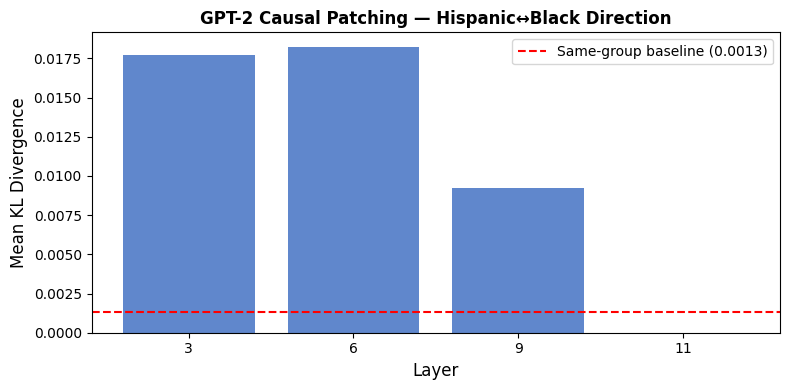


Next step: run 08_permutation_test_gpt2.ipynb to get permutation-validated p-values.


In [ ]:
layer_means = df.groupby('layer')['mean_kl'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(layer_means.index.astype(str), layer_means.values, color='#4472C4', alpha=0.85)
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Mean KL Divergence', fontsize=12)
ax.set_title('GPT-2 Causal Patching — Hispanic↔Black Direction', fontsize=12, fontweight='bold')
ax.axhline(np.mean(baseline_kls), color='red', linestyle='--', linewidth=1.5,
           label=f'Same-group baseline ({np.mean(baseline_kls):.4f})')
ax.legend()
plt.tight_layout()
plt.savefig('results/causal_patching_gpt2.png', dpi=300, bbox_inches='tight')
print('Saved: results/causal_patching_gpt2.png')
plt.show()
print('\nNext step: run 08_permutation_test_gpt2.ipynb to get permutation-validated p-values.')
